<a href="https://colab.research.google.com/github/agil-p-varghese/12345-stackup/blob/master/MicroGrad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [87]:
class Value:
  def __init__(self,data,_children=(),_op='',label=''):
    self.data=data
    self.grad=0.0
    self._backward=lambda: None
    self._prev=set(_children)
    self._op=_op
    self.label=label

  def __repr__(self):
    return f"Value(data={self.data})"
  def __add__(self,other):
    out=Value(self.data+other.data,(self,other),'+')

    def _backward():
      self.grad+=1.0*out.grad
      other.grad+=1.0*out.grad
    out._backward=_backward

    return out

  def __mul__(self,other):
    out=Value(self.data*other.data,(self,other),'*')

    def _backward():
      self.grad+=other.data*out.grad
      other.grad+=self.data*out.grad
    out._backward=_backward

    return out

  def tanh(self):
    x=self.data
    t=(math.exp(2*x)-1)/(math.exp(2*x)+1)
    out=Value(t,(self,),'tanh')

    def _backward():
      self.grad+=(1-t**2)*out.grad
    out._backward=_backward

    return out

  def backward(self):
    topo=[]
    visited=set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)

    build_topo(self)

    self.grad=1.0
    for node in reversed(topo):
      node._backward()


# --- Now, build the graph and run backward ---
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.8813735870195432, label='b')

x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1xx2w2 = x1w1 + x2w2; x1w1xx2w2.label = 'x1*w1 + x2*w2'
n = x1w1xx2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

# Run backpropagation
o.backward()

# Print gradients to verify
print(f"o.grad: {o.grad}")
print(f"n.grad: {n.grad}")
print(f"x1.grad: {x1.grad}")
print(f"w1.grad: {w1.grad}")
print(f"b.grad: {b.grad}")

o.grad: 1.0
n.grad: 0.4999999999999999
x1.grad: -1.4999999999999996
w1.grad: 0.9999999999999998
b.grad: 0.4999999999999999


In [16]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

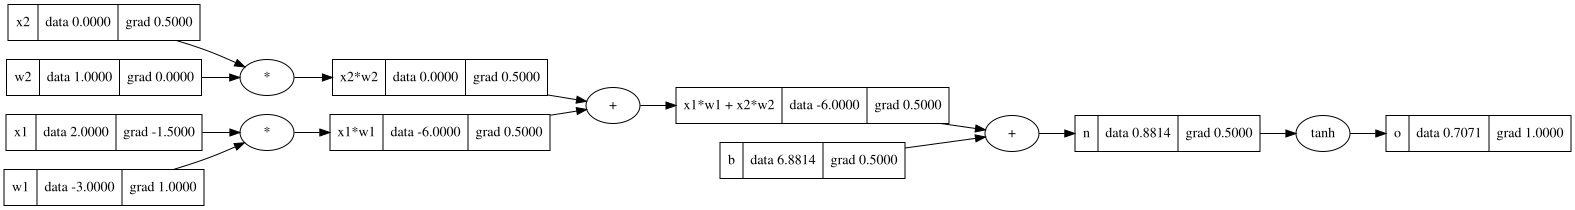

In [88]:
draw_dot(o)

In [83]:
# --- Now, build the graph and run backward ---
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.8813735870195432, label='b')

x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1xx2w2 = x1w1 + x2w2; x1w1xx2w2.label = 'x1*w1 + x2*w2'
n = x1w1xx2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

# Run backpropagation
o.backward()

# Print gradients to verify
print(f"o.grad: {o.grad}")
print(f"n.grad: {n.grad}")
print(f"x1.grad: {x1.grad}")
print(f"w1.grad: {w1.grad}")
print(f"b.grad: {b.grad}")

o.grad: 0.0
n.grad: 0.0
x1.grad: 0.0
w1.grad: 0.0
b.grad: 0.0
